In [2]:
# Install and load necessary packages
library(randomForest)
library(caret)
library(readxl)

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.

Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:randomForest’:

    margin


Loading required package: lattice



In [3]:
## Read excel 
became = data.frame(t(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1)))

## Remove the first 10 columns (not lipids)
became_num = became[-c(1:10),]

## Cast data to numeric type 
rownames(became_num) = paste0('X',rownames(became_num))
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}

In [4]:
## Read previously processed data 
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')
response_name = 'cluster'

## Subset only the patients from the BECAME cohort
became_data = scaled_df[rownames(subset(meta,cohort=='BECAME' & group=='HFpEF')),]

In [5]:
## Subset the metadata 
became_meta = meta[rownames(became_data),]

## Log transform the intensities 
became_data = log(became_num[rownames(became_data),])
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),response_name]=='B1'))

## Create train/test indices 
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

## Define training data 
x = became_data[index,]
y = became_data[index,'response_var']

In [6]:

# Assuming that 'x' is the dataframe of lipid measurements and 'y' is the binary response variable
set.seed(123)  # For reproducibility

# Combine the dataset
# data <- cbind(x, response_var = y)
data = x 

# Train the Random Forest model
rfModel <- randomForest(response_var ~ ., data = data, ntree = 500)

# Get variable importance
importance <- importance(rfModel)
# Rank the variable importance
featureRank <- rank(-importance[, "MeanDecreaseGini"], ties.method = "min")

# Use RFE to find the best subset of features
controlRF <- rfeControl(
  functions = rfFuncs,  # Random Forest model functions
  method = "repeatedcv",  # Cross-validation
  repeats = 5,  # Number of repeats for cross-validation
  verbose = FALSE
)

rfeModel <- rfe(
  x = data[, -ncol(data)],  # Exclude the response variable
  y = data$response_var,
  sizes = c(1:ncol(x)),  # Range of feature subset sizes to consider
  rfeControl = controlRF
)

# Examine the results
print(rfeModel)

# The optimal number of features
optimalFeatures <- predictors(rfeModel)
print(optimalFeatures)

# Final Random Forest Model based on optimal features
optimalModel <- randomForest(response_var ~ ., data = data[, c(optimalFeatures, "response_var")], ntree = 500)

# Evaluate the final model on the test set
predictions <- predict(optimalModel, became_data[-index,])
confusionMatrix(predictions, became_data[-index,]$response_var)


Recursive feature selection

Outer resampling method: Cross-Validated (10 fold, repeated 5 times) 

Resampling performance over subset size:

 Variables Accuracy  Kappa AccuracySD KappaSD Selected
         1   0.7571 0.3427    0.14661  0.3982         
         2   0.8262 0.5006    0.12722  0.3774         
         3   0.8657 0.6076    0.11471  0.3471         
         4   0.8857 0.6567    0.11407  0.3562         
         5   0.8818 0.6374    0.11286  0.3651         
         6   0.8851 0.6534    0.10010  0.3237         
         7   0.8846 0.6416    0.09932  0.3357         
         8   0.8739 0.6016    0.10083  0.3502         
         9   0.8776 0.6217    0.10524  0.3507         
        10   0.8719 0.6048    0.11655  0.3720         
        11   0.8739 0.5932    0.10488  0.3651         
        12   0.8682 0.5814    0.11604  0.3777         
        13   0.8686 0.5790    0.12140  0.3967         
        14   0.8654 0.5745    0.11723  0.3786         
        15   0.8711 0.5885    0.

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 22  3
         1  1  4
                                          
               Accuracy : 0.8667          
                 95% CI : (0.6928, 0.9624)
    No Information Rate : 0.7667          
    P-Value [Acc > NIR] : 0.1381          
                                          
                  Kappa : 0.5862          
                                          
 Mcnemar's Test P-Value : 0.6171          
                                          
            Sensitivity : 0.9565          
            Specificity : 0.5714          
         Pos Pred Value : 0.8800          
         Neg Pred Value : 0.8000          
             Prevalence : 0.7667          
         Detection Rate : 0.7333          
   Detection Prevalence : 0.8333          
      Balanced Accuracy : 0.7640          
                                          
       'Positive' Class : 0               
                                    

In [7]:
optimalFeatures <- predictors(rfeModel)
print(optimalFeatures)

 [1] "X94"  "X214" "X121" "X191" "X19"  "X97"  "X93"  "X202" "X92"  "X58" 
[11] "X105" "X188" "X201" "X197" "X127" "X173" "X200" "X228" "X186" "X107"
[21] "X166" "X22"  "X122" "X129" "X87"  "X2"   "X56"  "X213" "X5"   "X190"
[31] "X167" "X126" "X217" "X174" "X96"  "X15"  "X198" "X183" "X209" "X32" 


In [10]:
library(ggfortify)
p1 = autoplot(prcomp(data[,grepl('^X',colnames(data))]),data=meta[rownames(data),],col='cluster')
p2 = autoplot(prcomp(data[,optimalFeatures]),data=meta[rownames(data),],col='cluster')

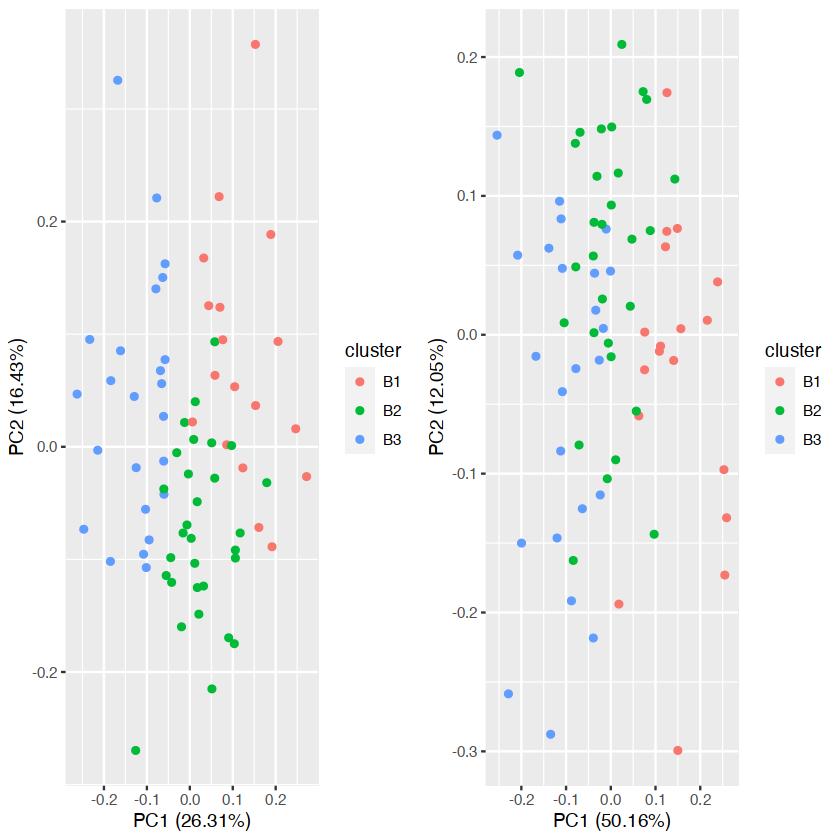

In [11]:
cowplot::plot_grid(p1,p2,ncol=2)

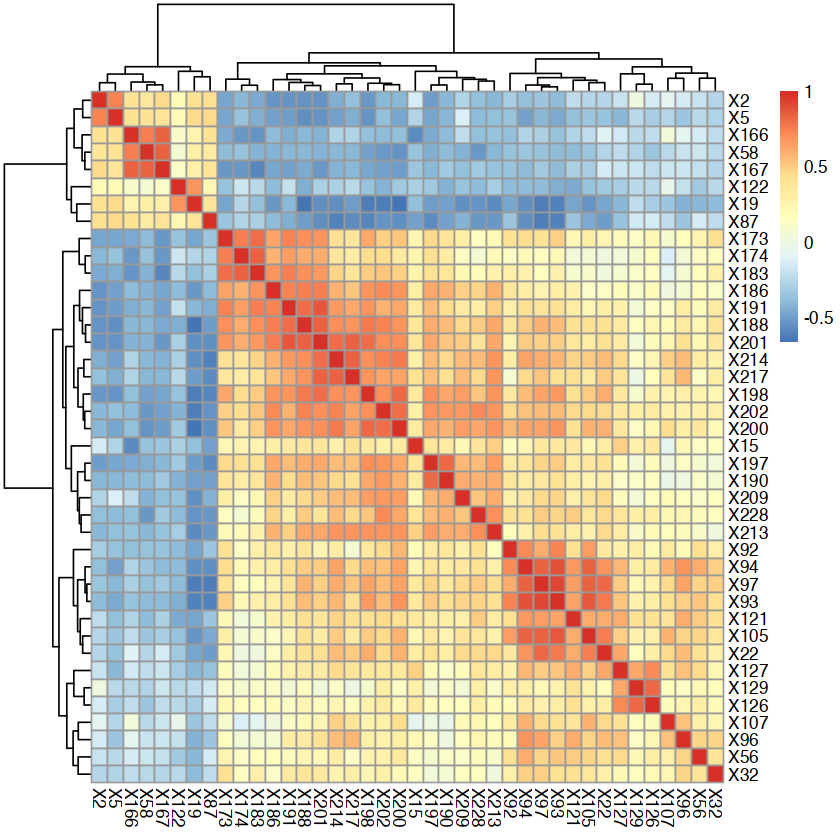

In [13]:
pheatmap::pheatmap(cor(data[,optimalFeatures]))